# Geometriai adat elemzés óra beadandó

Project célja CNN hálózat tervezése amely képes vezetni az f1tenth car ROS2 alapokra épülő modell autót.

### A project keszítése során a python=3.10 es verzióját alkalmaztam. <br> A használathoz szükséges környezet elkészítéséhez adott a `requirements.txt` file

### Tanító adatok letöltése

In [1]:
URL = "https://drive.google.com/file/d/1WFc9w7-muFVrxuDtfqILtH3ICtCPeesi/view?usp=sharing"
TRAIN_DATA_FOLDER = "./"

In [2]:
import gdown
import zipfile
import io
import os

# Download into memory
print("Downloading...")
buffer = io.BytesIO()
gdown.download(url=URL, output=buffer, quiet=False, fuzzy=True)

# Extract directly from memory
print("Extracting...")
os.makedirs(TRAIN_DATA_FOLDER, exist_ok=True)
buffer.seek(0)
with zipfile.ZipFile(buffer) as zf:
    zf.extractall(TRAIN_DATA_FOLDER)

print(f"Done! Data available in {TRAIN_DATA_FOLDER}")

Downloading...


Downloading...
From (original): https://drive.google.com/uc?id=1WFc9w7-muFVrxuDtfqILtH3ICtCPeesi
From (redirected): https://drive.google.com/uc?id=1WFc9w7-muFVrxuDtfqILtH3ICtCPeesi&confirm=t&uuid=a92bd338-bc72-46df-8cd8-d65338f23872
To: <_io.BytesIO object at 0x7d34404cd5d0>
100%|██████████| 633M/633M [00:42<00:00, 14.8MB/s] 


Extracting...
Done! Data available in ./


### A letöltőtt adatok betöltése `numpy` tömbökbe valamit az input label párok előállítása

In [3]:
import json
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras import models
import tensorflow as tf
import cv2
from scipy import ndimage

I0000 00:00:1779262883.775832   11810 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779262884.151558   11810 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779262885.194905   11810 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
X = []
y = []
FOLDER=TRAIN_DATA_FOLDER+"/train_data"

base_dirs = os.listdir(FOLDER)


for base_dir in base_dirs:

    # Load the JSON data
    with open(FOLDER+"/"+base_dir+"/joy_data.json", "r") as file:
        json_data = json.load(file)

    # Convert JSON data to pandas DataFrame
    # Create a list of dictionaries for each entry in the JSON file
    data = []
    for timestamp, info in tqdm(json_data.items()):
        try:
            image = Image.open(os.path.join(FOLDER+"/"+base_dir+"/images",f"{timestamp}.png")).resize((160, 120))
            img_normalized = np.asarray(image, dtype=np.float32) / 255.0  # Normalize

            X.append(img_normalized)
            y.append(info.get("axes",[0.0])[2])
            
        except:
            continue

# Convert to NumPy arrays
X = np.array(X, dtype=np.float32) 
y = np.array(y, dtype=np.float32)

print(f"Loaded {len(X)} samples.")
print(f"Image shape: {X[0].shape if len(X) > 0 else 'N/A'}")
print(f"Labels shape: {y.shape}")

100%|██████████| 2332/2332 [00:09<00:00, 245.63it/s]

Loaded 1796 samples.
Image shape: (120, 160, 3)
Labels shape: (1796,)


### Ahogy lathato a kepek az utat ábrazolják ez az `input` a `label` pedig az aktualis kormany adat 

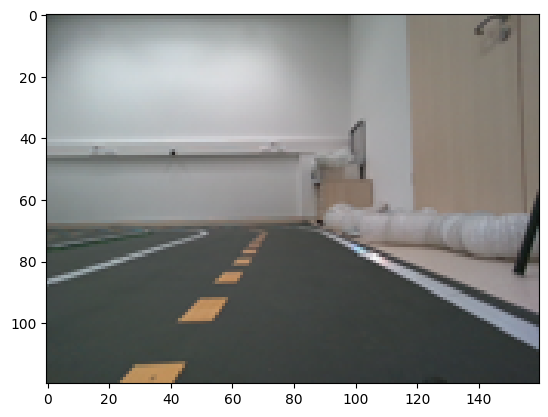

In [5]:
#pelda kep 
img = X[10]
plt.imshow(img)

In [6]:
print(y[10])

-0.0


### Az intervallun pedig a következőképp értelmezendő

`-1` - balra fordulás <br>
`0` - középen van a kormány <br>
`1` - jobbra fordulás 

## CNN modell definiálása

Nagyban hasonlít az NVIDIA-DAVE2 önvezető modelljére

In [7]:
model = Sequential([
    
    Conv2D(24, (5, 5),strides=(2,2) ,activation='relu', input_shape=(120, 160, 3)),
    Conv2D(36, (5, 5),strides=(2,2) ,activation='relu'),
    Conv2D(48, (5, 5),strides=(2,2) ,activation='relu'),
    Conv2D(64, (3, 3),strides=(2,2) ,activation='relu'),
    Conv2D(64, (3, 3),strides=(2,2) ,activation='relu'),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='tanh')  
])

def lr_scheduler(epoch, lr):
    if epoch < 10:
        return 1e-3  # First 10 epochs, learning rate is 1e-3
    elif epoch < 20:
        return 1e-4  # Next 10 epochs, learning rate is 1e-4
    else:
        return 1e-5  # After 20 epochs, learning rate is 1e-5


# Compile the model
#model.compile(optimizer=Adam(learning_rate=1e-4), loss='mse', metrics=['mae'])
model.compile(optimizer=Adam(learning_rate=1e-3), loss=tf.keras.losses.Huber(), metrics=['mae', 'mse'])

lr_scheduler_callback = LearningRateScheduler(lr_scheduler, verbose=1)

/home/xavier11/miniconda3/envs/geo_data/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1779262898.138877   11810 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6121 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


### CNN tanítása a modósítatlan adatokon

In [8]:
history_raw = model.fit(X, y, batch_size=4, epochs=30, validation_split=0.1, callbacks=[lr_scheduler_callback])
model.summary()


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/30


I0000 00:00:1779262899.609485   12503 service.cc:153] XLA service 0x7d303c039420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779262899.609506   12503 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779262899.653918   12503 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779262899.841489   12503 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779262899.852036   12503 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3234__.16


 44/404 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1575 - mae: 0.4544 - mse: 0.3191

I0000 00:00:1779262904.018175   12503 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


404/404 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.1281 - mae: 0.4226 - mse: 0.2589 - val_loss: 0.0708 - val_mae: 0.2451 - val_mse: 0.1415 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0919 - mae: 0.3423 - mse: 0.1843 - val_loss: 0.0754 - val_mae: 0.2784 - val_mse: 0.1509 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0904 - mae: 0.3320 - mse: 0.1815 - val_loss: 0.0561 - val_mae: 0.2593 - val_mse: 0.1123 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.001.
Epoch 4/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0860 - mae: 0.3257 - mse: 0.1727 - val_loss: 0.0821 - val_mae: 0.3710 - val_mse: 0.1641 - learning_rate: 0.0010

Epoch 5: LearningRateScheduler setting learning rate to 0.001.
Epoch 5/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss:

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 58, 78, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 37, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 17, 48)     │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 572,993 (2.19 MB)

 Trainable params: 190,997 (746.08 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 381,996 (1.46 MB)

### modell kimentésre GRAD-CAM előtt 

In [9]:
os.makedirs("./modells", exist_ok=True)
model.save("./modells/raw.keras")
print("Modell saved")

Modell saved


In [10]:
conv_layers = [layer for layer in model.layers if 'conv' in layer.name]
layer_names = [layer.name for layer in conv_layers]
layer_outputs = [layer.output for layer in conv_layers]
img = np.expand_dims(img, axis=0)
activation_model = models.Model(inputs=model.layers[0].input, outputs=layer_outputs)
activations = activation_model.predict(img)

for name, act in zip(layer_names, activations):
    print(f'{name}: {act.shape}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step
conv2d: (1, 58, 78, 24)
conv2d_1: (1, 27, 37, 36)
conv2d_2: (1, 12, 17, 48)
conv2d_3: (1, 5, 8, 64)
conv2d_4: (1, 2, 3, 64)


### Első Layer vizualizációja

first layer activation shape: (1, 58, 78, 24)


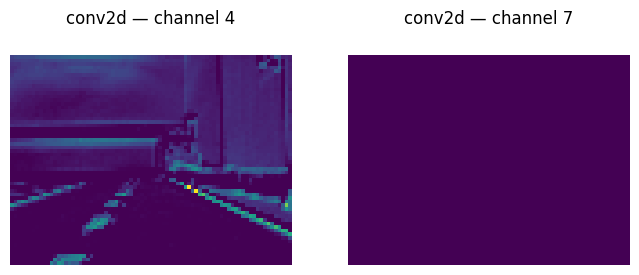

In [11]:
first_layer_activation = activations[0]
print('first layer activation shape:', first_layer_activation.shape)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].matshow(first_layer_activation[0, :, :, 4], cmap='viridis')
axes[0].set_title(f'{layer_names[0]} — channel 4')
axes[0].axis('off')
axes[1].matshow(first_layer_activation[0, :, :, 7], cmap='viridis')
axes[1].set_title(f'{layer_names[0]} — channel 7')
axes[1].axis('off')
plt.show()

### Összes CONV layer vizualízációja 

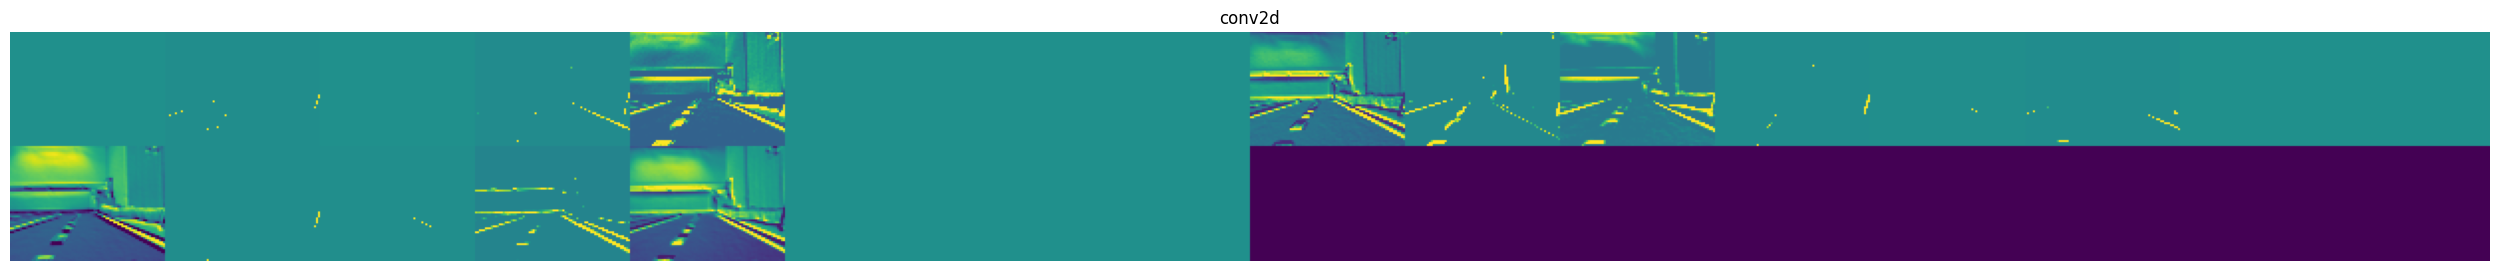

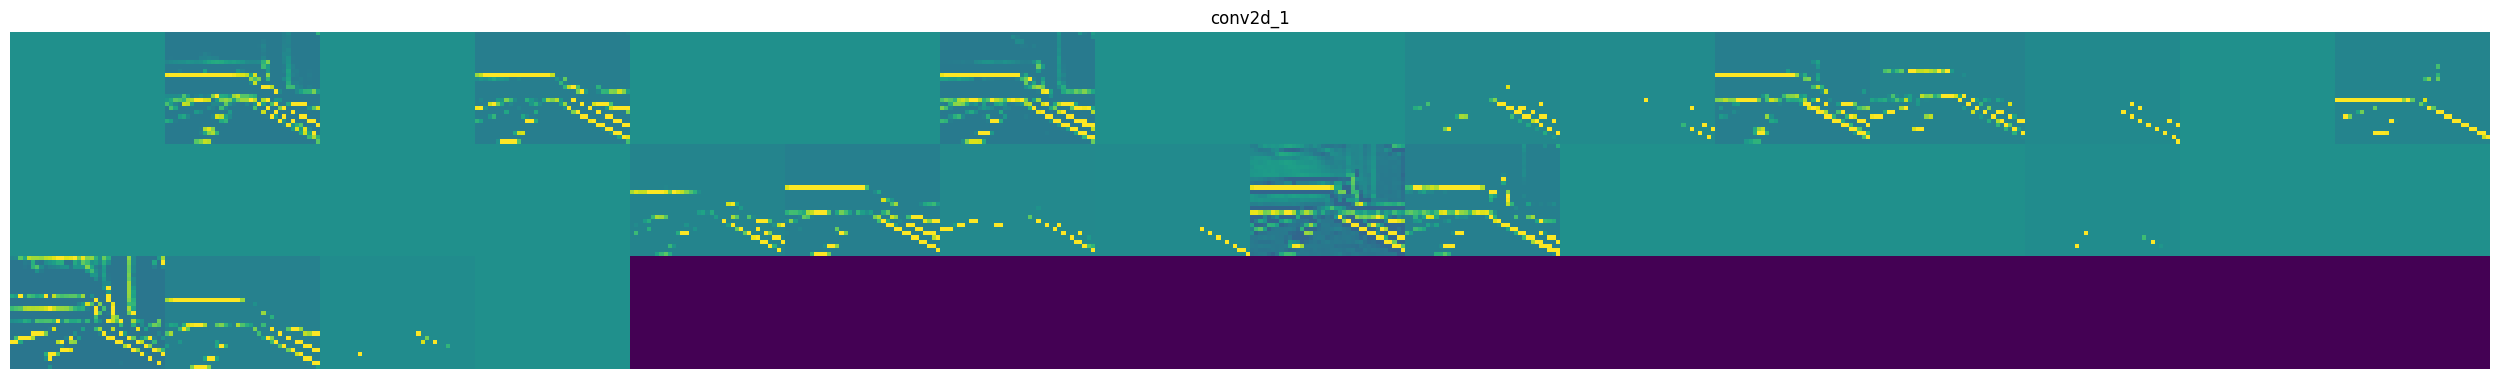

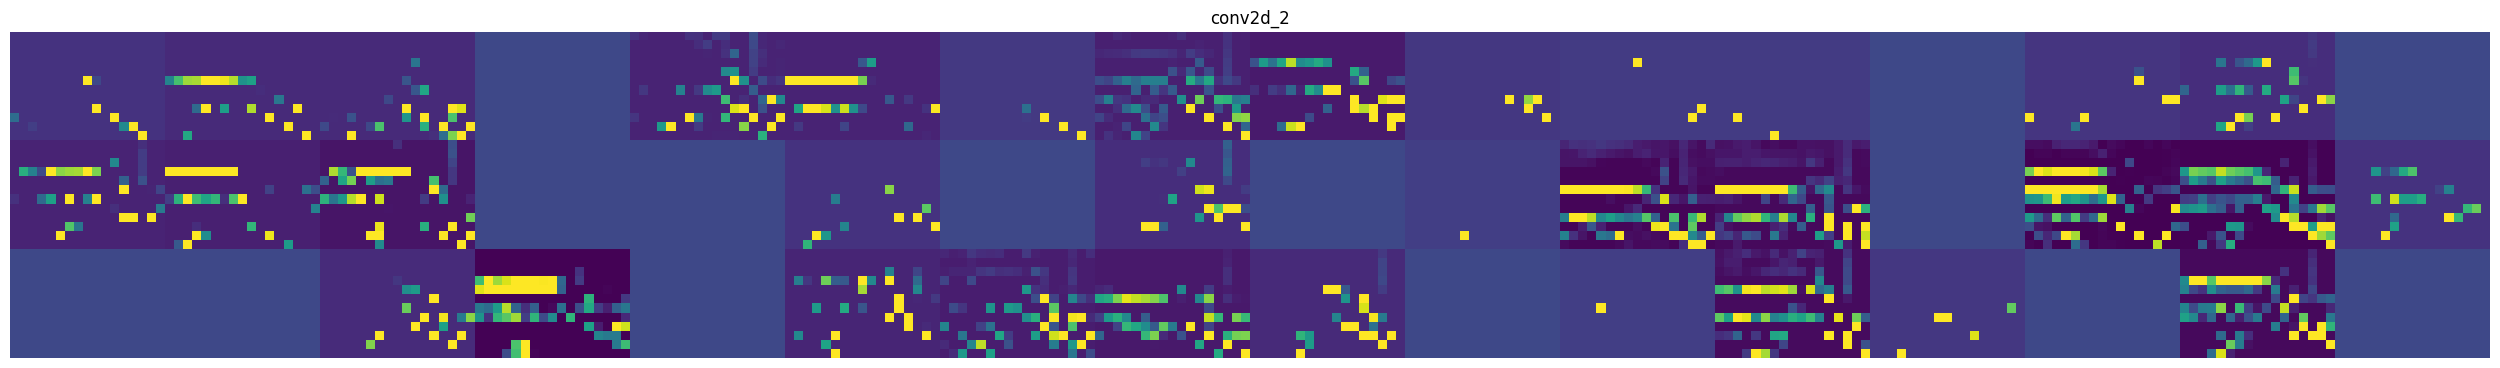

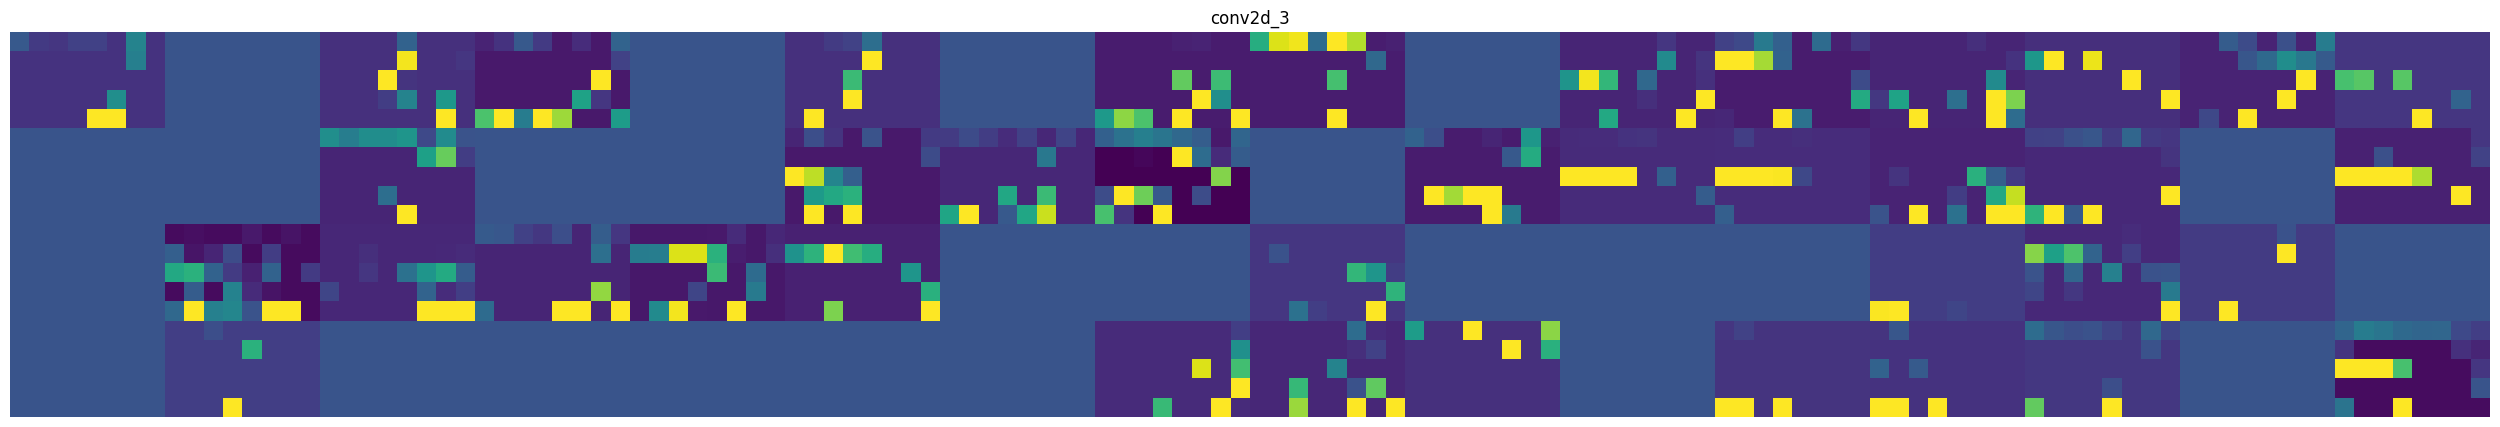

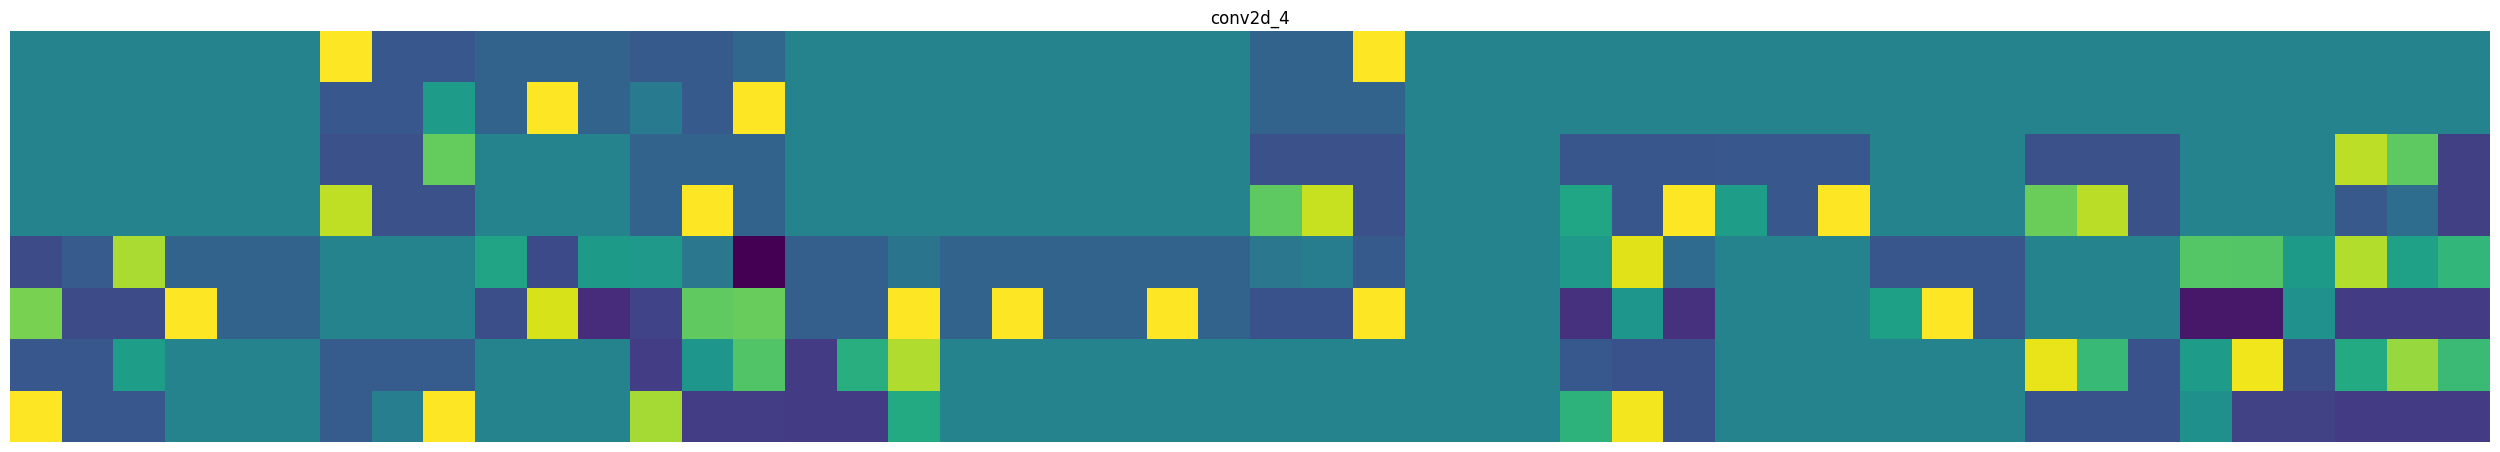

In [12]:
images_per_row = 16

for layer_name, layer_activation in zip(layer_names, activations):
    n_features = layer_activation.shape[-1]
    h = layer_activation.shape[1]
    w = layer_activation.shape[2]

    cols_per_row = min(images_per_row, n_features)
    n_cols = int(np.ceil(n_features / cols_per_row))
    display_grid = np.zeros((h * n_cols, cols_per_row * w))

    for col in range(n_cols):
        for row in range(cols_per_row):
            idx = col * cols_per_row + row
            if idx >= n_features:
                continue
            channel_image = layer_activation[0, :, :, idx].copy()
            channel_image -= channel_image.mean()
            std = channel_image.std()
            if std > 0:
                channel_image /= std
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[col * h:(col + 1) * h, row * w:(row + 1) * w] = channel_image

    scale = 1.0 / max(h, w)
    plt.figure(figsize=(scale * display_grid.shape[1] * 2,
                       scale * display_grid.shape[0] * 2))
    plt.title(layer_name)
    plt.grid(False)
    plt.axis('off')
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.show()

Amint látható a CNN modellnek nem az út élei hangsúlyosak hanem a falon található fehér fény visszaverődés

### Alkalmazzuk éldetektálási technikákat 

In [13]:
exp_img = X[510]

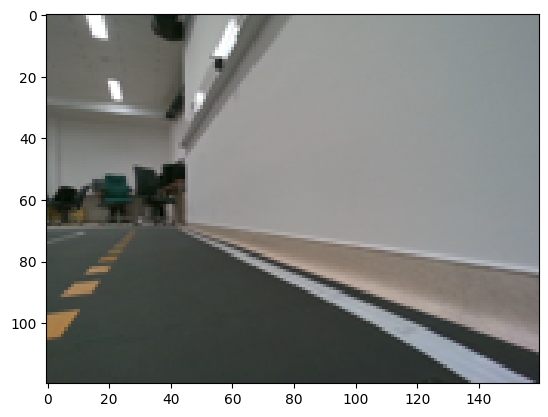

In [14]:
plt.imshow(exp_img)

### Kernelek definiálása

A két kernel az átlós irányú gradienseket számítja ki — egy függőleges és egy vízszintes irányban.

In [15]:
roberts_cross_v = np.array([[1,  0],
                             [0, -1]])

roberts_cross_h = np.array([[ 0, 1],
                             [-1, 0]])

### Szürkeárnyalatos konverzió

A konvolúció előtt az RGB képet szürkeárnyalatossá alakítjuk, mivel az él detektáláshoz csak az intenzitásértékekre van szükség.

In [16]:
gray = cv2.cvtColor(exp_img, cv2.COLOR_RGB2GRAY)

### Konvolúció alkalmazása

A kerneleket ráalkalmazzuk a szürkeárnyalatos képre. Az eredmény megmutatja, hogy az egyes irányokban mekkora az intenzitásváltozás.

In [17]:
vertical   = ndimage.convolve(gray, roberts_cross_v)
horizontal = ndimage.convolve(gray, roberts_cross_h)

### Gradiens magnitúdó kiszámítása

A két irány eredményéből kiszámítjuk a teljes él erősségét a Pitagorasz-tétel segítségével, majd 0–255 közé skálázzuk.

In [18]:
edged_img = np.sqrt(np.square(horizontal) + np.square(vertical))
edged_img *= 255

### Kép felső részének maszkolása

A kép felső 70 sora általában a motorháztető vagy az ég — ezeket nullázzuk ki, mivel nem relevánsak az útél detektáláshoz.

In [19]:
edged_img[:70, :] = 0

### Eredmény megjelenítése

Az eredeti és az él detektált kép egymás mellett.

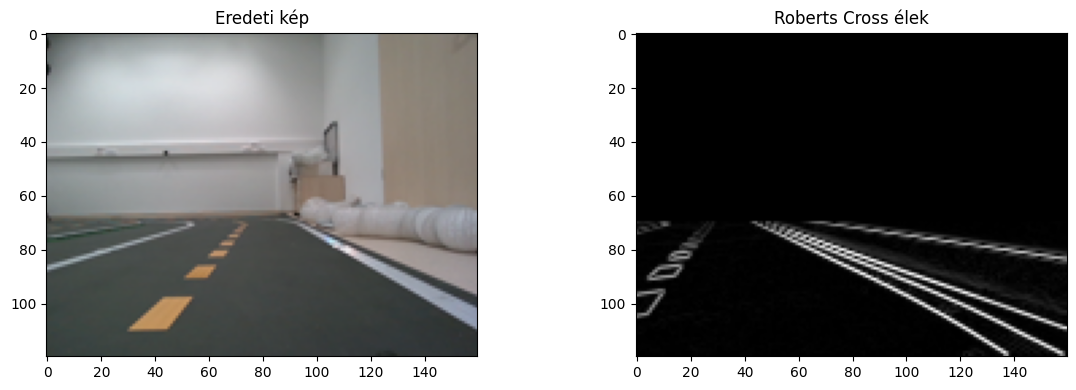

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(image)
axes[0].set_title("Eredeti kép")
axes[1].imshow(edged_img, cmap="gray")
axes[1].set_title("Roberts Cross élek")
plt.tight_layout()
plt.show()

## Mi az a Roberts Cross?

A Roberts Cross egy 1963-ban Lawrence Roberts által kifejlesztett él detektáló algoritmus. 
Az egyik legegyszerűbb és legrégebbi ilyen módszer, amely két 2x2-es kernel segítségével 
az átlós irányú intenzitásváltozásokat — vagyis az éleket — emeli ki a képen.

### Hogyan működik?

A módszer lényege a **konvolúció**: a kerneleket végigcsúsztatjuk a képen, és minden 
pixelnél kiszámítjuk a szomszédos pixelek közötti különbséget.

- A **függőleges kernel** a ↘ irányú változásokat érzékeli
- A **vízszintes kernel** a ↗ irányú változásokat érzékeli

A két eredményből a **gradiens magnitúdót** számítjuk:

$$G = \sqrt{G_x^2 + G_y^2}$$

ahol $G_x$ és $G_y$ a két irányban kapott konvolúció eredménye.

### Előnyök és hátrányok

| ✅ Előny | ❌ Hátrány |
|---|---|
| Egyszerű és gyors | Zajérzékeny |
| Könnyen érthető | Kis kernel → kevésbé pontos |
| Kis számítási igény | Vastag éleket nem kezel jól |

### Mikor érdemes használni?

Akkor hasznos, ha egyszerű, kontrasztos képeken szeretnénk gyorsan éleket detektálni — 
például sávkövetésnél, ahol az út vonalai jól elkülönülnek a háttértől.

## Roberts Cross él detektálás — színes kiemeléssel

Az előző verzióhoz képest most az éleket nem szürkeárnyalatosan jelenítjük meg, 
hanem **piros színnel jelöljük meg az eredeti képen**.

In [21]:
edged_img[:70, :] = 0

result = exp_img.copy()
edge_mask = edged_img > 30
result[edge_mask] = [255, 0, 0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


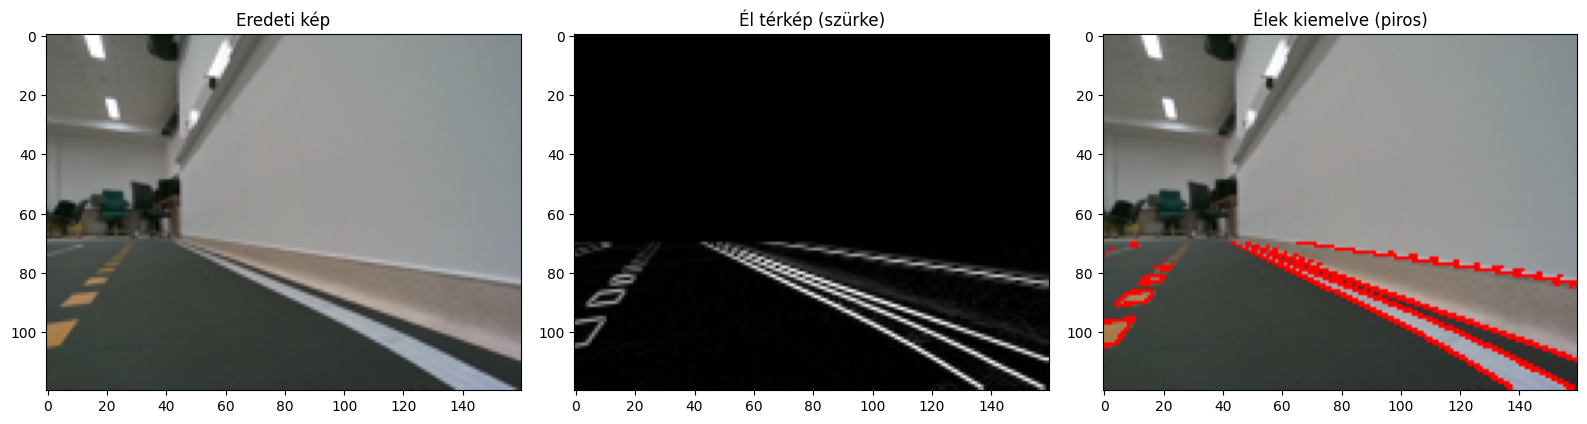

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].imshow(exp_img)
axes[0].set_title("Eredeti kép")
axes[1].imshow(edged_img, cmap="gray")
axes[1].set_title("Él térkép (szürke)")
axes[2].imshow(result)
axes[2].set_title("Élek kiemelve (piros)")
plt.tight_layout()
plt.show()

### Az Robert éldetektálás alkalmazása a tanító adatokon és uj modell tanítása

In [23]:
# ehez szukseges fuggveny definiálása
def highlight_edges_robert(img):
    roberts_cross_v = np.array([[1,  0],
                                [0, -1]])
    roberts_cross_h = np.array([[0,  1],
                                [-1, 0]])

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    vertical   = ndimage.convolve(gray, roberts_cross_v)
    horizontal = ndimage.convolve(gray, roberts_cross_h)

    edged_img = np.sqrt(np.square(horizontal) + np.square(vertical))
    edged_img = (edged_img / edged_img.max() * 255).astype(np.uint8)
    edged_img[:70, :] = 0
    edge_mask = edged_img > 30 
    result = img.copy()
    result[edge_mask] = [255, 0, 0]  # RGB red

    return result

### Élkiemelés elhelyezése az eredeti képeken

In [24]:
X_edge = np.array([highlight_edges_robert(img=img) for img in tqdm(X)])

100%|██████████| 1796/1796 [00:00<00:00, 4501.21it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


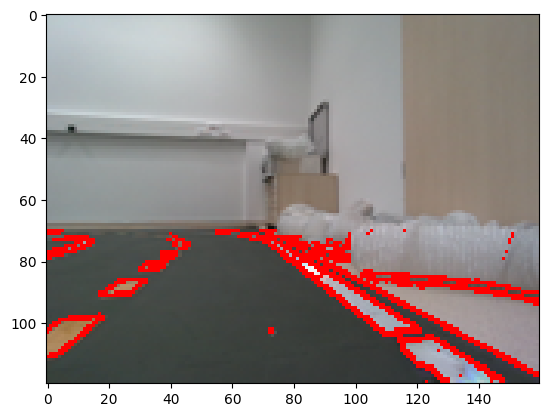

In [25]:
plt.imshow(X_edge[40])

In [26]:
model_edge = Sequential([
    Conv2D(24, (5, 5), strides=(2,2), activation='relu', input_shape=(120, 160, 3)),
    Conv2D(36, (5, 5), strides=(2,2), activation='relu'),
    Conv2D(48, (5, 5), strides=(2,2), activation='relu'),
    Conv2D(64, (3, 3), strides=(2,2), activation='relu'),
    Conv2D(64, (3, 3), strides=(2,2), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='tanh')
])

model_edge.compile(optimizer=Adam(learning_rate=1e-3), loss=tf.keras.losses.Huber(), metrics=['mae', 'mse'])

history_edge = model_edge.fit(X_edge, y, batch_size=4, epochs=30, validation_split=0.1, callbacks=[lr_scheduler_callback])

model_edge.save("./modells/edge.keras")
print("Edge model saved")


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/30


I0000 00:00:1779262962.245413   12505 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_75666__.16


404/404 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3259 - mae: 0.6209 - mse: 0.6947 - val_loss: 0.3007 - val_mae: 0.6160 - val_mse: 0.6014 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3245 - mae: 0.6191 - mse: 0.6909 - val_loss: 0.3007 - val_mae: 0.6160 - val_mse: 0.6014 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3245 - mae: 0.6191 - mse: 0.6909 - val_loss: 0.3007 - val_mae: 0.6160 - val_mse: 0.6014 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.001.
Epoch 4/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3245 - mae: 0.6191 - mse: 0.6909 - val_loss: 0.3007 - val_mae: 0.6160 - val_mse: 0.6014 - learning_rate: 0.0010

Epoch 5: LearningRateScheduler setting learning rate to 0.001.
Epoch 5/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss:

## GRAD-CAM — Éldetektált modell aktivációinak vizualizációja

Ugyanaz az aktiváció-megjelenítés, amit az eredeti modellnél is alkalmaztunk, most a `model_edge` modellre — azonos tesztképen.

## Loss összehasonlítás — eredeti vs. éldetektált modell

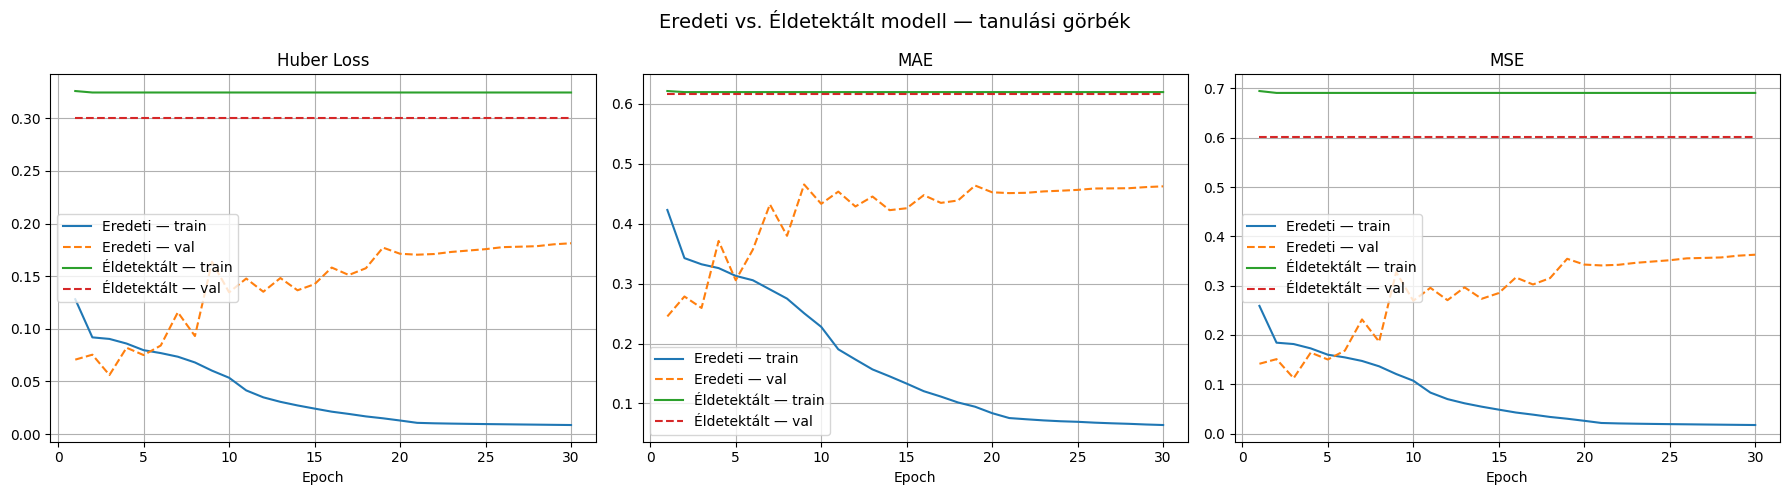

In [27]:
epochs = range(1, 31)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Loss ---
axes[0].plot(epochs, history_raw.history['loss'],      label='Eredeti — train')
axes[0].plot(epochs, history_raw.history['val_loss'],  label='Eredeti — val', linestyle='--')
axes[0].plot(epochs, history_edge.history['loss'],     label='Éldetektált — train')
axes[0].plot(epochs, history_edge.history['val_loss'], label='Éldetektált — val', linestyle='--')
axes[0].set_title('Huber Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

# --- MAE ---
axes[1].plot(epochs, history_raw.history['mae'],      label='Eredeti — train')
axes[1].plot(epochs, history_raw.history['val_mae'],  label='Eredeti — val', linestyle='--')
axes[1].plot(epochs, history_edge.history['mae'],     label='Éldetektált — train')
axes[1].plot(epochs, history_edge.history['val_mae'], label='Éldetektált — val', linestyle='--')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

# --- MSE ---
axes[2].plot(epochs, history_raw.history['mse'],      label='Eredeti — train')
axes[2].plot(epochs, history_raw.history['val_mse'],  label='Eredeti — val', linestyle='--')
axes[2].plot(epochs, history_edge.history['mse'],     label='Éldetektált — train')
axes[2].plot(epochs, history_edge.history['val_mse'], label='Éldetektált — val', linestyle='--')
axes[2].set_title('MSE')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Eredeti vs. Éldetektált modell — tanulási görbék', fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
edge_test_img = highlight_edges_robert(X[510])
edge_test_tensor = np.expand_dims(edge_test_img, axis=0)

conv_layers_edge = [layer for layer in model_edge.layers if 'conv' in layer.name]
layer_names_edge = [layer.name for layer in conv_layers_edge]
layer_outputs_edge = [layer.output for layer in conv_layers_edge]

activation_model_edge = models.Model(inputs=model_edge.layers[0].input, outputs=layer_outputs_edge)
activations_edge = activation_model_edge.predict(edge_test_tensor)

for name, act in zip(layer_names_edge, activations_edge):
    print(f'{name}: {act.shape}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
conv2d_5: (1, 58, 78, 24)
conv2d_6: (1, 27, 37, 36)
conv2d_7: (1, 12, 17, 48)
conv2d_8: (1, 5, 8, 64)
conv2d_9: (1, 2, 3, 64)


### Első layer — channel 4 és 7 (éldetektált modell)

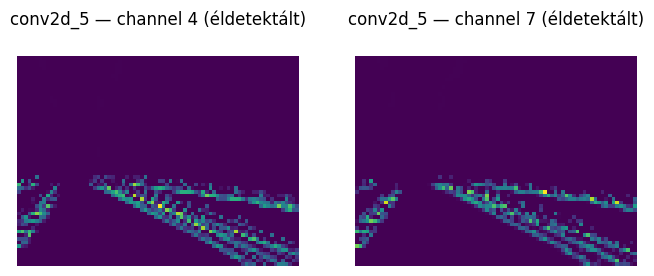

In [29]:
first_act_edge = activations_edge[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].matshow(first_act_edge[0, :, :, 4], cmap='viridis')
axes[0].set_title(f'{layer_names_edge[0]} — channel 4 (éldetektált)')
axes[0].axis('off')
axes[1].matshow(first_act_edge[0, :, :, 7], cmap='viridis')
axes[1].set_title(f'{layer_names_edge[0]} — channel 7 (éldetektált)')
axes[1].axis('off')
plt.show()

### Összes CONV layer vizualizációja (éldetektált modell)

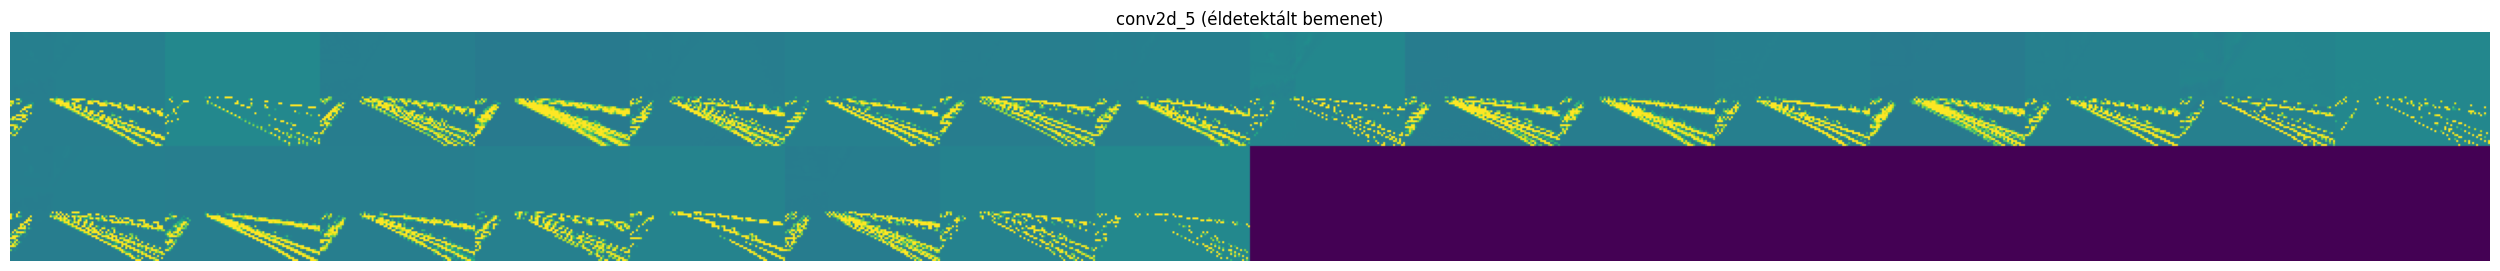

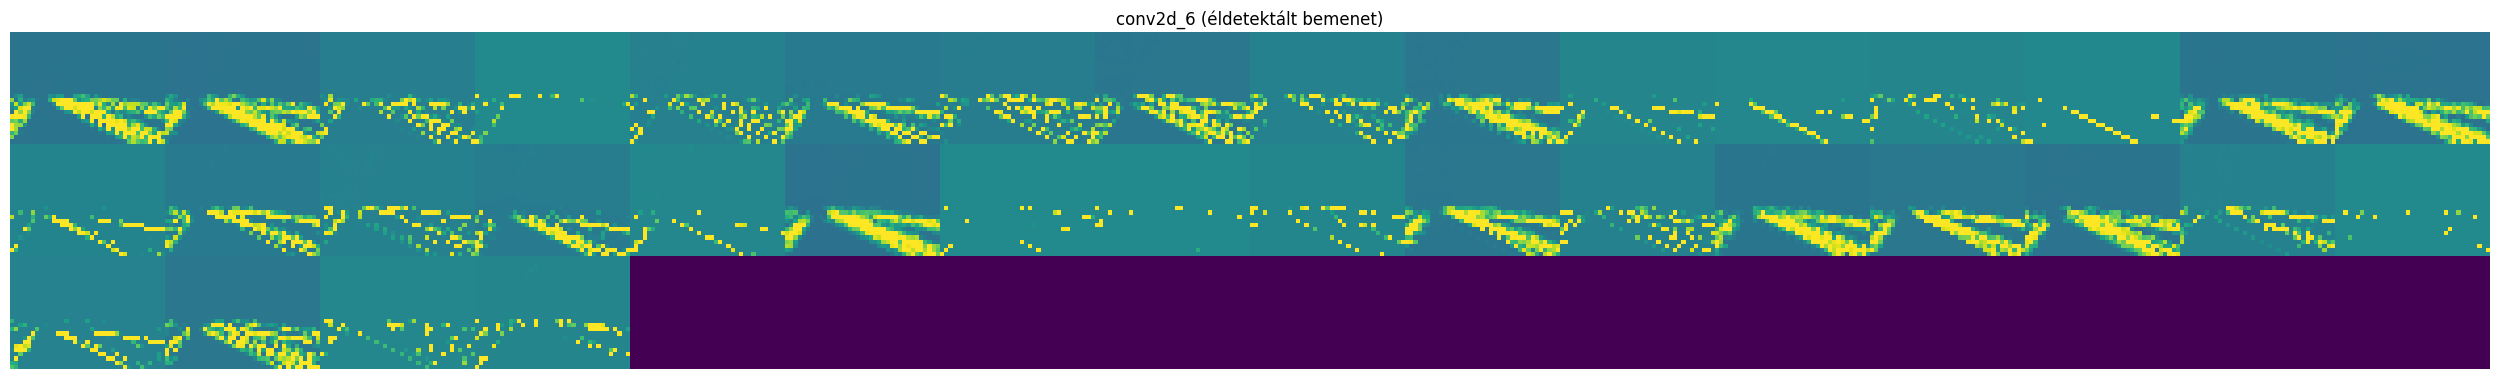

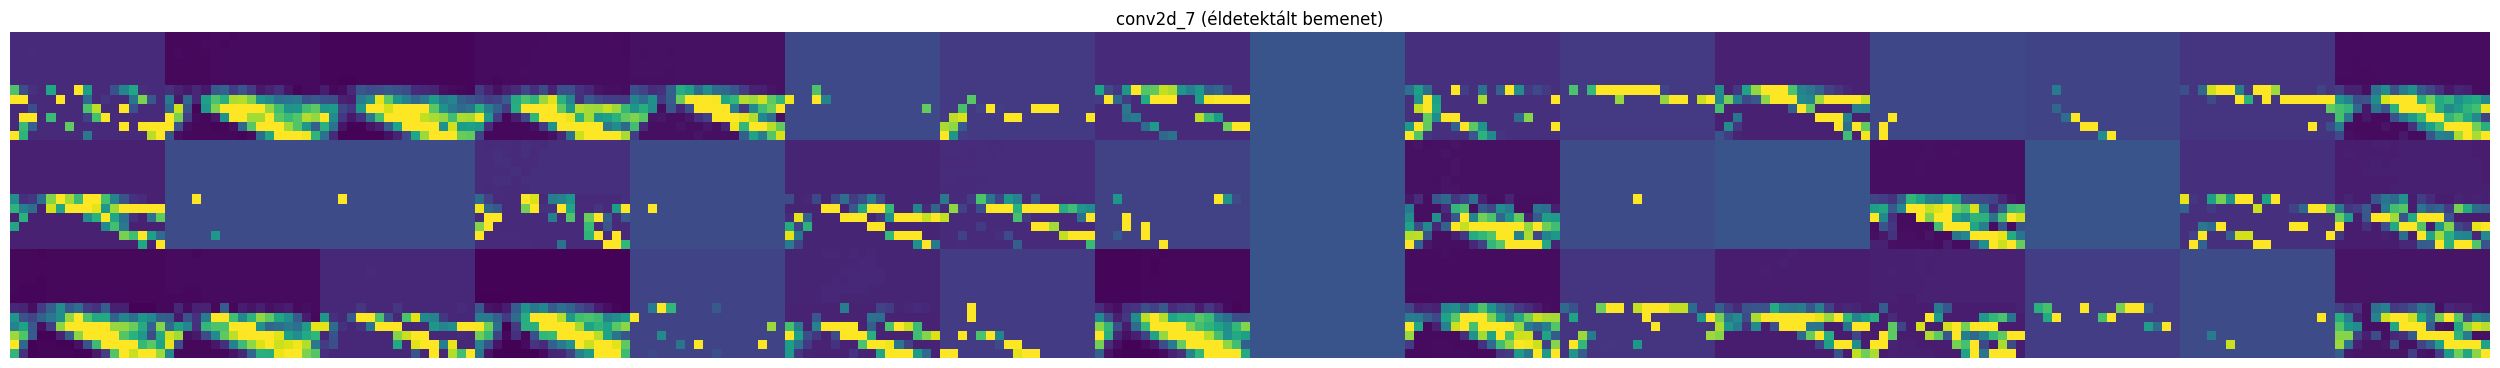

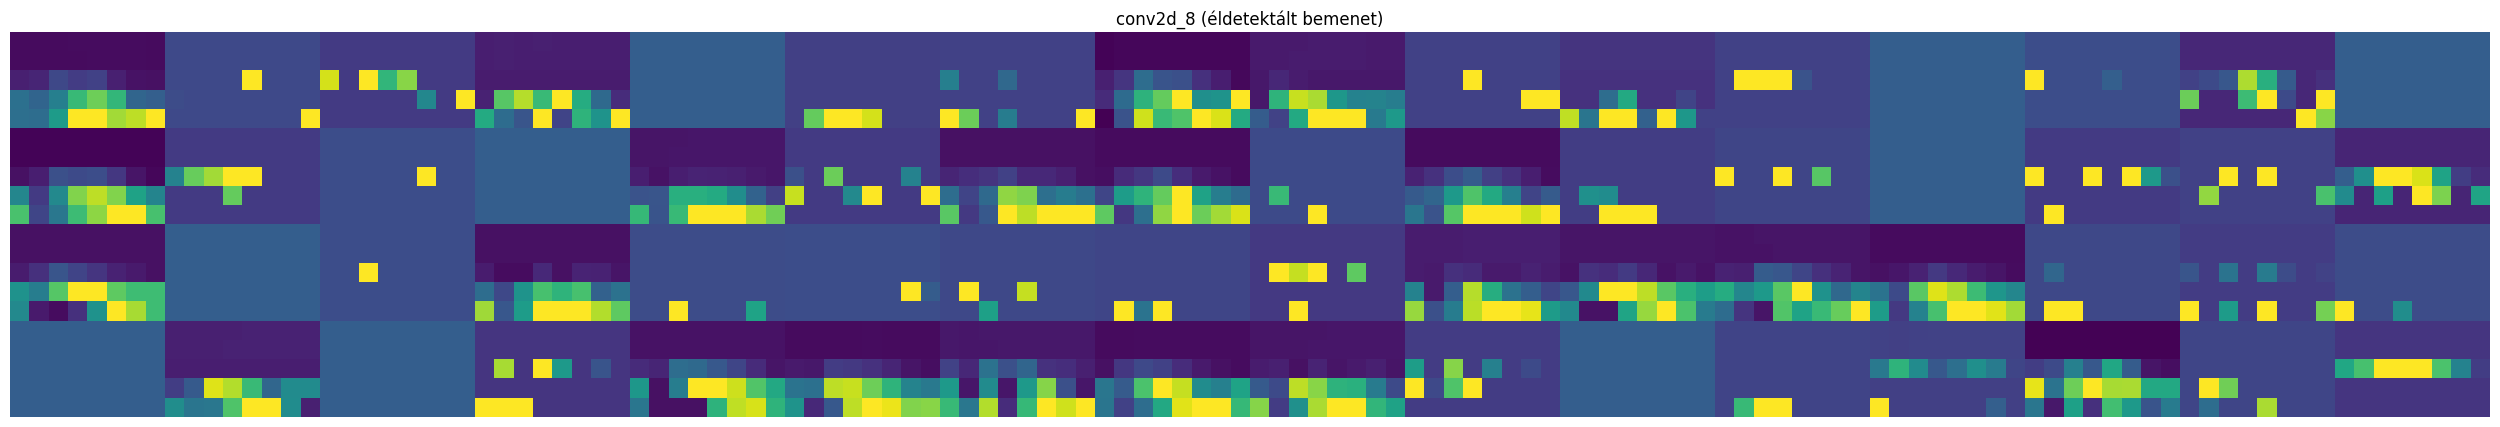

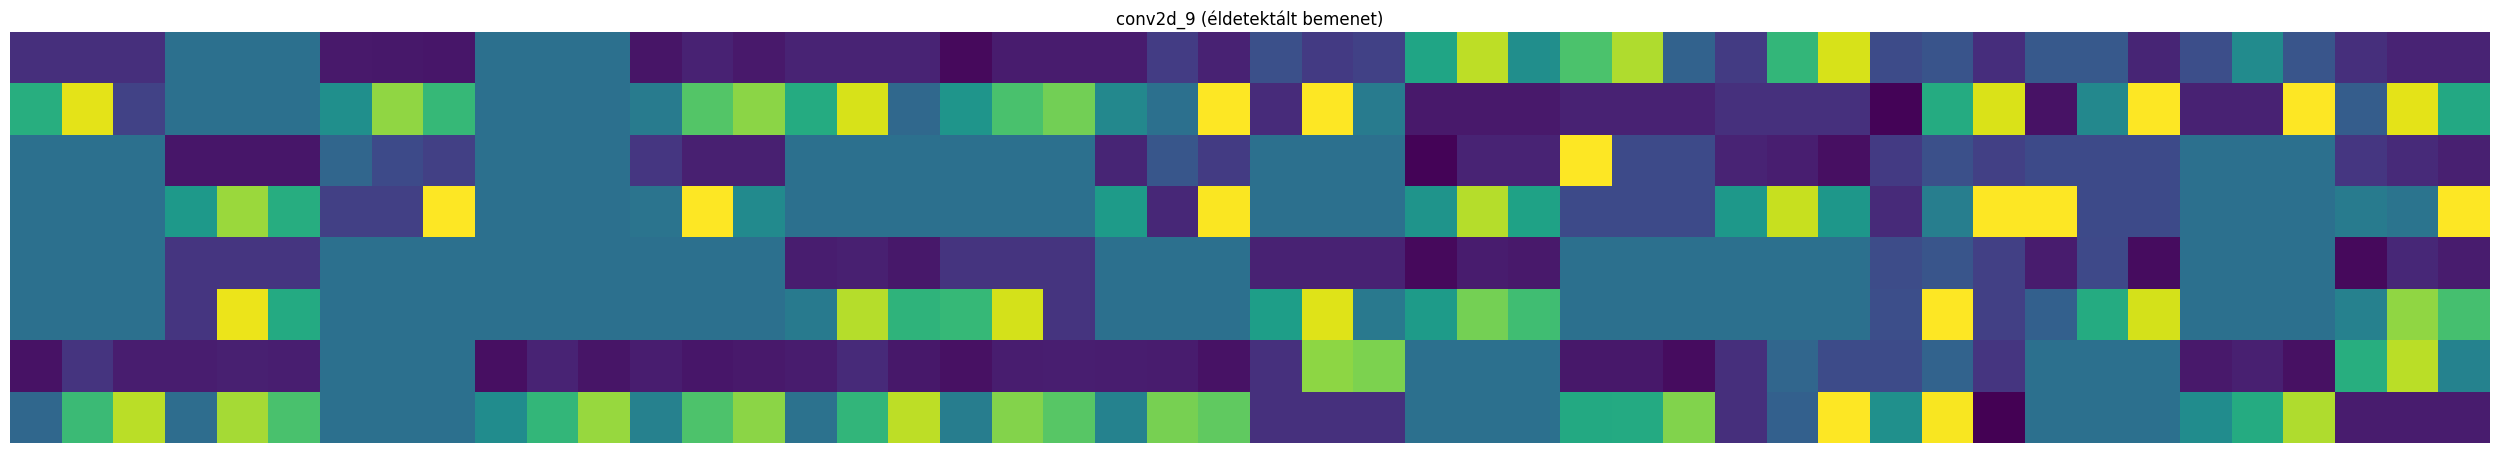

In [30]:
images_per_row = 16

for layer_name, layer_activation in zip(layer_names_edge, activations_edge):
    n_features = layer_activation.shape[-1]
    h = layer_activation.shape[1]
    w = layer_activation.shape[2]

    cols_per_row = min(images_per_row, n_features)
    n_cols = int(np.ceil(n_features / cols_per_row))
    display_grid = np.zeros((h * n_cols, cols_per_row * w))

    for col in range(n_cols):
        for row in range(cols_per_row):
            idx = col * cols_per_row + row
            if idx >= n_features:
                continue
            channel_image = layer_activation[0, :, :, idx].copy()
            channel_image -= channel_image.mean()
            std = channel_image.std()
            if std > 0:
                channel_image /= std
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[col * h:(col + 1) * h, row * w:(row + 1) * w] = channel_image

    scale = 1.0 / max(h, w)
    plt.figure(figsize=(scale * display_grid.shape[1] * 2,
                        scale * display_grid.shape[0] * 2))
    plt.title(f'{layer_name} (éldetektált bemenet)')
    plt.grid(False)
    plt.axis('off')
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.show()

## Összehasonlítás: eredeti vs. éldetektált modell tanulása

### Mi változott az aktivációkban?

Az aktivaciok amint lathato volt athelyezodtek a az ut eleire viszont nagyban segitett az hogy mas azon van a hangsuly a loss viselkedeset meg kutatom tovabb 

### Következtetés

A modell pontosssaganak novelesehez a kesobbiekben tobb adatot adok at a halonak valamint augmentaciot is esetlegesen alkamazok 